# Library Versions

In [1]:
# Install the compatible pair for your new Colab runtime
!pip install tensorflow==2.16.1
!pip install tensorflow-io==0.37.1
!pip install ml_dtypes==0.5.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 589.9/589.9 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: ml-dtypes
   

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 92.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 49.1 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.1 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.16.1 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.16.1 which is incompatible.
tf-keras 2.19.0 requi

# Access GCS Bucket

In [1]:
# Run this cell first

import os
from google.colab import userdata
import json

# --- 1. Securely get the key from Colab Secrets ---
key_string = userdata.get('GCP_KEY')
key_data = json.loads(key_string)

# --- 2. Authenticate gsutil ---
# Write the key to a temporary file that gsutil can read
with open('temp_key.json', 'w') as f:
    json.dump(key_data, f)

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = 'temp_key.json'
!gcloud auth activate-service-account --key-file=temp_key.json

# --- 3. Access bucket directories ---
BUCKET_NAME = "asvspoof-la-data-bucket"
!gsutil ls gs://{BUCKET_NAME}

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]
gs://asvspoof-la-data-bucket/ASVspoof2019_LA_cm_protocols/
gs://asvspoof-la-data-bucket/ASVspoof2019_LA_dev/
gs://asvspoof-la-data-bucket/ASVspoof2019_LA_eval/
gs://asvspoof-la-data-bucket/ASVspoof2019_LA_train/
gs://asvspoof-la-data-bucket/models/
gs://asvspoof-la-data-bucket/tfrecords/


# Datasets

### TFRecord Creation (only once)

In [2]:
import pandas as pd
import tensorflow as tf
import tensorflow_io as tfio
import numpy as np
import json
import os
from google.colab import userdata
from tqdm.auto import tqdm # For a progress bar!

# --- 1. Authentication & Setup ---
# This cell is self-contained. It re-creates the key file
# for the GCS write operations.
KEY_FILE_NAME = 'temp_key.json'
try:
    key_string = userdata.get('GCP_KEY')
    key_data = json.loads(key_string)
    with open(KEY_FILE_NAME, 'w') as f:
        json.dump(key_data, f)

    # Set the environment variable for TF
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_FILE_NAME
    # Activate gcloud for shell commands (just in case)
    !gcloud auth activate-service-account --key-file={KEY_FILE_NAME}
    print("✅ Auth activated.")
except Exception as e:
    print(f"⚠️ Auth failed, but may already be active: {e}")

storage_options = {'token': KEY_FILE_NAME}

# --- 2. Define All Constants ---
SAMPLE_RATE = 16000
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
BUCKET_NAME = "asvspoof-la-data-bucket"
PROTOCOL_DIR = "ASVspoof2019_LA_cm_protocols"
AUDIO_DIR = "ASVspoof2019_LA_train"
DEV_AUDIO_DIR = "ASVspoof2019_LA_dev"
EVAL_AUDIO_DIR = "ASVspoof2019_LA_eval" # <-- ADDED FOR EVAL

# --- 3. Load Label Files ---
print("Loading label files from GCS...")
column_names = ['SPEAKER_ID', 'AUDIO_FILE_NAME', 'BLANK', 'SYSTEM_ID', 'KEY']

# Load TRAINING Labels
train_protocol_path = f"gs://{BUCKET_NAME}/{PROTOCOL_DIR}/ASVspoof2019.LA.cm.train.trn.txt"
train_df = pd.read_csv(
    train_protocol_path, sep=' ', header=None,
    names=column_names, storage_options=storage_options
)
train_df = train_df[['AUDIO_FILE_NAME', 'KEY']]
train_df['LABEL'] = train_df['KEY'].apply(lambda x: 0 if x == 'bonafide' else 1)
train_df = train_df.drop(columns=['KEY'])
print(f"✅ Loaded {len(train_df)} training labels.")

# Load VALIDATION Labels
dev_protocol_path = f"gs://{BUCKET_NAME}/{PROTOCOL_DIR}/ASVspoof2019.LA.cm.dev.trl.txt"
val_df = pd.read_csv(
    dev_protocol_path, sep=' ', header=None,
    names=column_names, storage_options=storage_options
)
val_df = val_df[['AUDIO_FILE_NAME', 'KEY']]
val_df['LABEL'] = val_df['KEY'].apply(lambda x: 0 if x == 'bonafide' else 1)
val_df = val_df.drop(columns=['KEY'])
print(f"✅ Loaded {len(val_df)} validation labels.")

# Load EVALUATION Labels <-- ADDED
eval_protocol_path = f"gs://{BUCKET_NAME}/{PROTOCOL_DIR}/ASVspoof2019.LA.cm.eval.trl.txt"
eval_df = pd.read_csv(
    eval_protocol_path, sep=' ', header=None,
    names=column_names, storage_options=storage_options
)
eval_df = eval_df[['AUDIO_FILE_NAME', 'KEY']]
eval_df['LABEL'] = eval_df['KEY'].apply(lambda x: 0 if x == 'bonafide' else 1)
eval_df = eval_df.drop(columns=['KEY'])
print(f"✅ Loaded {len(eval_df)} evaluation labels.")


# --- 4. Pre-compute Mel Filterbank ---
num_spectrogram_bins = N_FFT // 2 + 1
mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=N_MELS,
    num_spectrogram_bins=num_spectrogram_bins,
    sample_rate=SAMPLE_RATE,
    lower_edge_hertz=0.0,
    upper_edge_hertz=(SAMPLE_RATE / 2.0)
)
print("✅ Mel filterbank pre-computed.")

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]
✅ Auth activated.
Loading label files from GCS...
✅ Loaded 25380 training labels.
✅ Loaded 24844 validation labels.
✅ Loaded 71237 evaluation labels.
✅ Mel filterbank pre-computed.


In [3]:
# --- 5. Define Processing Function (Python-native version) ---
def load_and_preprocess_eager(audio_file_name, gcs_audio_dir):
    # Use f-string, as this is eager Python
    gcs_path = f"gs://{BUCKET_NAME}/{gcs_audio_dir}/flac/{audio_file_name}.flac"

    audio_binary = tf.io.read_file(gcs_path)
    waveform = tfio.audio.decode_flac(audio_binary, dtype=tf.int16)
    waveform = tf.cast(waveform, tf.float32) / 32768.0
    waveform = tf.squeeze(waveform, axis=-1)

    stft = tf.signal.stft(waveform, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    mel_spectrogram = tf.tensordot(spectrogram, mel_filterbank, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    # Set dynamic shape. This is important for variable-length audio.
    log_mel_spectrogram.set_shape([None, N_MELS])

    return log_mel_spectrogram

# --- 6. Define TFRecord Helper Functions ---
def _bytes_feature(value):
    """Returns a bytes_list from a string / byte."""
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    """Returns an int64_list from a bool / enum / int / uint."""
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(spectrogram, label):
    """
    Creates a tf.train.Example message ready to be written to a file.
    """
    spec_string = tf.io.serialize_tensor(spectrogram)

    feature = {
        'spectrogram': _bytes_feature(spec_string.numpy()),
        'label': _int64_feature(label)
    }

    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()


# --- 7. Define Main Writer Function ---
def process_and_write_tfrecords(df, gcs_audio_dir, gcs_output_path):
    """
    Loops through a DataFrame, processes audio, and writes to a TFRecord file on GCS.
    """
    print(f"\nStarting to process {len(df)} files...")
    print(f"Writing to: {gcs_output_path}")

    with tf.io.TFRecordWriter(gcs_output_path) as writer:
        for _, row in tqdm(df.iterrows(), total=len(df)):
            file_name = row['AUDIO_FILE_NAME']
            label = row['LABEL']

            try:
                spectrogram = load_and_preprocess_eager(file_name, gcs_audio_dir)
                example = serialize_example(spectrogram, label)
                writer.write(example)
            except Exception as e:
                print(f"\nWARNING: Skipping file {file_name}. Error: {e}")

    print(f"\n✅ Successfully created {gcs_output_path}")

# --- 8. RUN THE CONVERSION ---

# Define output paths
TFRECORD_DIR = "tfrecords"
GCS_TRAIN_OUTPUT_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/train.tfrecord"
GCS_VAL_OUTPUT_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/val.tfrecord"
GCS_EVAL_OUTPUT_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/eval.tfrecord" # <-- ADDED

In [ ]:
# Process the Training Set
process_and_write_tfrecords(
    df=train_df,
    gcs_audio_dir=AUDIO_DIR,
    gcs_output_path=GCS_TRAIN_OUTPUT_PATH
)

# Process the Validation Set
process_and_write_tfrecords(
    df=val_df,
    gcs_audio_dir=DEV_AUDIO_DIR,
    gcs_output_path=GCS_VAL_OUTPUT_PATH
)

# Process the Evaluation Set <-- ADDED
process_and_write_tfrecords(
    df=eval_df,
    gcs_audio_dir=EVAL_AUDIO_DIR,
    gcs_output_path=GCS_EVAL_OUTPUT_PATH
)

# --- 9. Clean up ---
!rm {KEY_FILE_NAME}
print("\n🎉 All processing complete. Key file removed.")

### Train

In [4]:
import os
from google.colab import userdata
import json

KEY_FILE_NAME = 'temp_key.json'
try:
    key_string = userdata.get('GCP_KEY')
    key_data = json.loads(key_string)
    with open(KEY_FILE_NAME, 'w') as f:
        json.dump(key_data, f)

    # Authenticate Python (for TF, Pandas)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_FILE_NAME
    # Authenticate Shell (for !gsutil)
    !gcloud auth activate-service-account --key-file={KEY_FILE_NAME}

    print("✅ Auth activated.")
except Exception as e:
    print(f"⚠️ Auth failed, but may already be active: {e}")

# Define your bucket and TFRecord folder
BUCKET_NAME = "asvspoof-la-data-bucket"
TFRECORD_DIR = "tfrecords"

# Test the connection by listing your new files
print("\nListing your new TFRecord files:")
!gsutil ls gs://{BUCKET_NAME}/{TFRECORD_DIR}/

Activated service account credentials for: [colab-storage-reader@voiceauth-479800.iam.gserviceaccount.com]
✅ Auth activated.

Listing your new TFRecord files:
gs://asvspoof-la-data-bucket/tfrecords/eval.tfrecord
gs://asvspoof-la-data-bucket/tfrecords/train.tfrecord
gs://asvspoof-la-data-bucket/tfrecords/val.tfrecord


In [5]:
import tensorflow as tf

# --- 1. Define Constants ---
BATCH_SIZE = 32
N_MELS = 128      # Must match the N_MELS from your creation script
SHUFFLE_BUFFER = 10000 # Use a large buffer for good shuffling

# --- 2. Define GCS File Paths ---
GCS_TRAIN_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/train.tfrecord"
GCS_VAL_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/val.tfrecord"
GCS_EVAL_PATH = f"gs://{BUCKET_NAME}/{TFRECORD_DIR}/eval.tfrecord"

# --- 3. The TFRecord Parser Function ---
# This is the "decoder" for your .tfrecord files.
def parse_tfrecord_fn(example_proto):
    # 1. Define the feature "schema"
    # This must EXACTLY match what you used in serialize_example
    feature_description = {
        'spectrogram': tf.io.FixedLenFeature([], tf.string),
        'label': tf.io.FixedLenFeature([], tf.int64),
    }

    # 2. Parse the input `example_proto`
    example = tf.io.parse_single_example(example_proto, feature_description)

    # 3. Deserialize the spectrogram string back into a tensor
    spectrogram = tf.io.parse_tensor(example['spectrogram'], out_type=tf.float32)

    # 4. CRITICAL: Set the dynamic shape.
    # This tells padded_batch that the first dimension is unknown (time)
    # but the second dimension is fixed (N_MELS).
    spectrogram.set_shape([None, N_MELS])

    # 5. Cast the label to float32 for the model's loss function
    label = tf.cast(example['label'], tf.float32)

    return spectrogram, label

# --- 4. Build the Final Datasets ---

# Load the training dataset
train_dataset = tf.data.TFRecordDataset(
    GCS_TRAIN_PATH, num_parallel_reads=tf.data.AUTOTUNE
)
train_dataset = (
    train_dataset.map(parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(SHUFFLE_BUFFER)
    .padded_batch(BATCH_SIZE, padded_shapes=([None, N_MELS], []))
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

print(f"✅ Training dataset:   {train_dataset}")

✅ Training dataset:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 128), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


### Validation

In [6]:
# Load the validation dataset
val_dataset = tf.data.TFRecordDataset(
    GCS_VAL_PATH, num_parallel_reads=tf.data.AUTOTUNE
)
val_dataset = (
    val_dataset.map(parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(BATCH_SIZE, padded_shapes=([None, N_MELS], []))
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

print(f"✅ Validation dataset: {val_dataset}")

✅ Validation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 128), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


### Test

In [7]:
# Load the evaluation dataset
eval_dataset = tf.data.TFRecordDataset(
    GCS_EVAL_PATH, num_parallel_reads=tf.data.AUTOTUNE
)
eval_dataset = (
    eval_dataset.map(parse_tfrecord_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(BATCH_SIZE, padded_shapes=([None, N_MELS], []))
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

print(f"✅ Evaluation dataset: {eval_dataset}")

✅ Evaluation dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 128), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


### Cleanup

In [ ]:
# --- 9. Clean up ---
!rm {KEY_FILE_NAME}
print("\n🎉 All processing complete. Key file removed.")

# CNN

# RNN

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Bidirectional, Masking, Dropout

# --- 1. Define Model Constants ---
N_MELS = 128 # Must match your data

# --- 2. Build the Model Architecture ---
model = Sequential([
    # Input shape is (batch, time, features) -> (None, None, 128)
    # The Masking layer will handle the padded time steps
    tf.keras.layers.Masking(mask_value=0.0, input_shape=(None, N_MELS)),

    # 1st Bidirectional GRU layer
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.3),

    # 2nd Bidirectional GRU layer
    Bidirectional(GRU(64, return_sequences=False)), # False = return only last output
    Dropout(0.3),

    # Dense hidden layer
    Dense(64, activation='relu'),
    Dropout(0.3),

    # Output layer
    # 1 output neuron (bonafide vs. spoof)
    # Sigmoid activation for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

# --- 3. Compile the Model ---
model.compile(
    # Adam is a great default optimizer
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    # BinaryCrossentropy is the standard loss for sigmoid
    loss='binary_crossentropy',

    # We want to track accuracy and AUC
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc') # Area Under the Curve
    ]
)

# --- 4. Print Summary ---
print("✅ Model compiled.")
model.summary()

✅ Model compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 256)      │       198,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,113 (1.26 MB)

 Trainable params: 330,113 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# --- 1. Define GCS Checkpoint Path ---
# (Make sure BUCKET_NAME is defined from your Auth cell)
CHECKPOINT_PATH = f"gs://{BUCKET_NAME}/models/best_model_tfrecord_v2.keras"
print(f"Best model will be saved to: {CHECKPOINT_PATH}")

# --- 2. Define Callbacks ---

# Save the best version of the model to GCS
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    save_weights_only=False,    # Save the entire model
    monitor="val_auc",          # The metric to monitor
    mode="max",                 # We want to MAXIMIZE AUC
    save_best_only=True         # Only save when it's the "best"
)

# Stop training early if the model stops improving
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,                 # Stop after 5 epochs of no improvement
    restore_best_weights=True   # Restore the weights from the best epoch
)

class_weights = {
    0: 1.0,  # Bonafide (baseline)
    1: 8.7   # Spoof (penalize errors ~8.7x more)
}

# --- 3. Define Training Parameters ---
EPOCHS = 20 # EarlyStopping will find the best epoch

# --- 4. Start Training ---
print("\nStarting model training...")
print("This should start immediately (no long caching wait).")

history = model.fit(
    train_dataset,              # Your NEW fast TFRecord dataset
    epochs=EPOCHS,
    validation_data=val_dataset, # Your NEW fast TFRecord dataset
    callbacks=[checkpoint_cb, early_stopping_cb],
    class_weight=class_weights
)

print("✅ Training complete.")
print(f"Best model was saved to {CHECKPOINT_PATH}")

Best model will be saved to: gs://asvspoof-la-data-bucket/models/best_model_tfrecord_v2.keras

Starting model training...
This should start immediately (no long caching wait).
Epoch 1/20
    794/Unknown 258s 279ms/step - accuracy: 0.9440 - auc: 0.9690 - loss: 0.2340

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


794/794 ━━━━━━━━━━━━━━━━━━━━ 332s 373ms/step - accuracy: 0.9441 - auc: 0.9690 - loss: 0.2339 - val_accuracy: 0.9610 - val_auc: 0.9515 - val_loss: 0.1559
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 318s 369ms/step - accuracy: 0.9898 - auc: 0.9936 - loss: 0.0518 - val_accuracy: 0.9212 - val_auc: 0.8571 - val_loss: 0.3649
Epoch 3/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 318s 368ms/step - accuracy: 0.9878 - auc: 0.9947 - loss: 0.0529 - val_accuracy: 0.9706 - val_auc: 0.9232 - val_loss: 0.1712
Epoch 4/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 323s 373ms/step - accuracy: 0.9951 - auc: 0.9968 - loss: 0.0261 - val_accuracy: 0.9909 - val_auc: 0.9887 - val_loss: 0.0370
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 323s 374ms/step - accuracy: 0.9969 - auc: 0.9983 - loss: 0.0172 - val_accuracy: 0.9921 - val_auc: 0.9911 - val_loss: 0.0317
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 321s 372ms/step - accuracy: 0.9962 - auc: 0.9968 - loss: 0.0204 - val_accuracy: 0.9863 - val_auc: 0.9744 - val_loss: 0.0637
Epoch 7/20
794/794 ━━━━━━━━

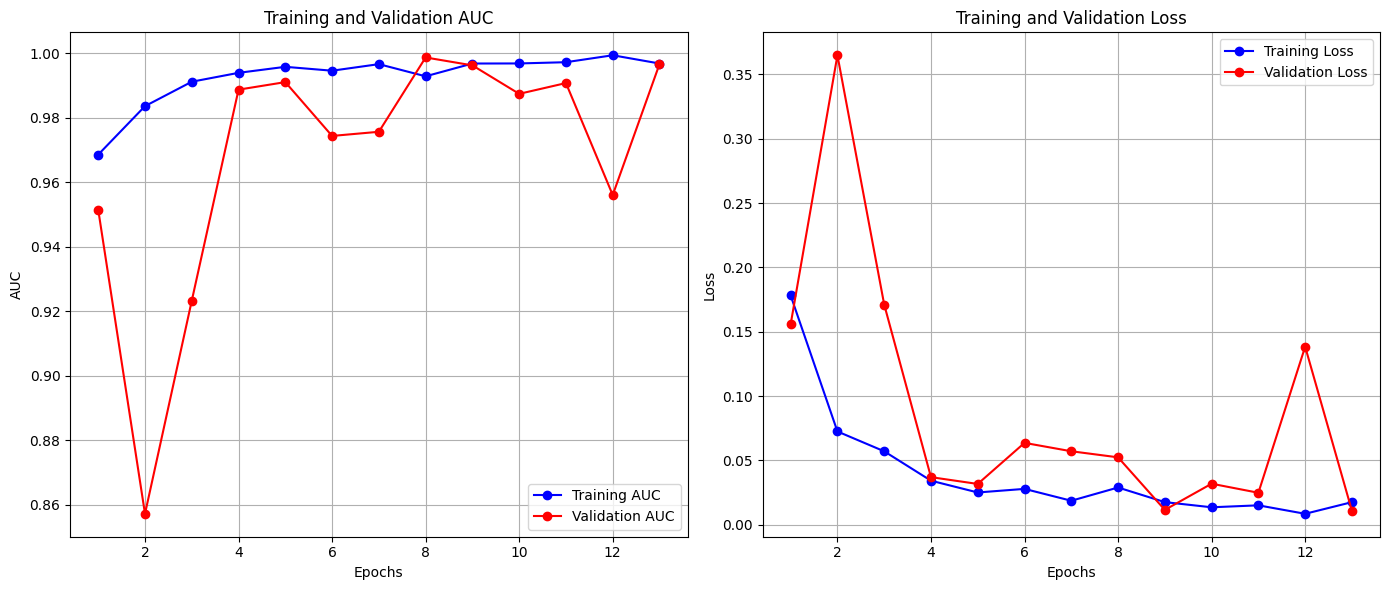

In [11]:
import matplotlib.pyplot as plt

# --- 1. Get the metrics from the history object ---
# Note: If you stopped and restarted, you might not have 'history'
# In that case, you'd need to re-run training.
try:
    history_dict = history.history

    # Get the 'auc' and 'val_auc'
    auc = history_dict['auc']
    val_auc = history_dict['val_auc']

    # Get the 'loss' and 'val_loss'
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']

    # Get the number of epochs
    epochs = range(1, len(auc) + 1)

    # --- 2. Plot Training & Validation AUC ---
    plt.figure(figsize=(14, 6))

    # Subplot 1: AUC
    plt.subplot(1, 2, 1)
    plt.plot(epochs, auc, 'bo-', label='Training AUC')
    plt.plot(epochs, val_auc, 'ro-', label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.xlabel('Epochs')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout() # Adjusts plots to prevent overlap
    plt.show()

except NameError:
    print("Oh no! The 'history' object was not found.")
    print("Please make sure you have just run the model.fit() cell.")
    print("If you restarted the kernel, you'll need to re-run training to generate this plot.")

In [15]:
import tensorflow as tf

# --- 1. Define Model Path ---
# This MUST match the CHECKPOINT_PATH from your training cell
BEST_MODEL_PATH = f"gs://{BUCKET_NAME}/models/best_model_tfrecord_v2.keras"

print(f"Loading best model from: {BEST_MODEL_PATH}")

try:
    # --- 2. Load the Saved Model ---
    # This loads the entire model (architecture, weights, optimizer state)
    # from the epoch with the highest 'val_auc'
    model = tf.keras.models.load_model(BEST_MODEL_PATH)

    print("\n✅ Model loaded successfully.")

    # --- 3. Evaluate on the Test (Eval) Dataset ---
    # This runs the model on the 'eval_dataset' which it has NEVER seen
    # during training or validation. This is your final, true score.
    print("\nEvaluating model performance on the test (eval) dataset...")

    # We must have the 'eval_dataset' variable from Cell 2 (the TFRecord pipeline)
    eval_results = model.evaluate(
        eval_dataset,
        return_dict=True # Returns results as a dictionary
    )

    print("\n--- 🏁 Final Evaluation Results ---")
    print(f"     Test Loss: {eval_results['loss']:.4f}")
    print(f" Test Accuracy: {eval_results['accuracy']:.4f}")
    print(f"      Test AUC: {eval_results['auc']:.4f}")

except tf.errors.NotFoundError:
    print(f"\n❌ ERROR: Model file not found at {BEST_MODEL_PATH}")
    print("Please check that your CHECKPOINT_PATH in the training cell is correct")
    print("and that the model.fit() cell ran and successfully saved the file.")
except NameError as e:
    print(f"\n❌ ERROR: A variable is missing: {e}")
    print("Please make sure you have run your 'Auth Cell' (for BUCKET_NAME)")
    print("and your 'TFRecord Pipeline Cell' (for eval_dataset) in this session.")

Loading best model from: gs://asvspoof-la-data-bucket/models/best_model_tfrecord_v2.keras

✅ Model loaded successfully.

Evaluating model performance on the test (eval) dataset...
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 175s 77ms/step - accuracy: 0.8774 - auc: 0.9323 - loss: 0.3569

--- 🏁 Final Evaluation Results ---
     Test Loss: 0.3618
 Test Accuracy: 0.8765
      Test AUC: 0.9322


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

print("Running predictions on the eval dataset to build confusion matrix...")

try:
    # --- 1. Get True Labels (y_true) ---
    # We need to loop over the eval_dataset to get all the true labels
    y_true = []
    for spectrograms, labels in eval_dataset:
        y_true.extend(labels.numpy())

    # Convert to a NumPy array
    y_true = np.array(y_true)

    # --- 2. Get Predicted Labels (y_pred) ---
    # First, get the raw sigmoid probabilities from the model
    y_pred_probs = model.predict(eval_dataset)

except NameError as e:
    print(f"\n❌ ERROR: A variable is missing: {e}")
    print("Please make sure you have run your 'TFRecord Pipeline Cell' (for eval_dataset)")
    print("and your 'Load Model Cell' (for model) in this session.")

Running predictions on the eval dataset to build confusion matrix...
2227/2227 ━━━━━━━━━━━━━━━━━━━━ 172s 77ms/step


✅ Predictions and labels are ready.


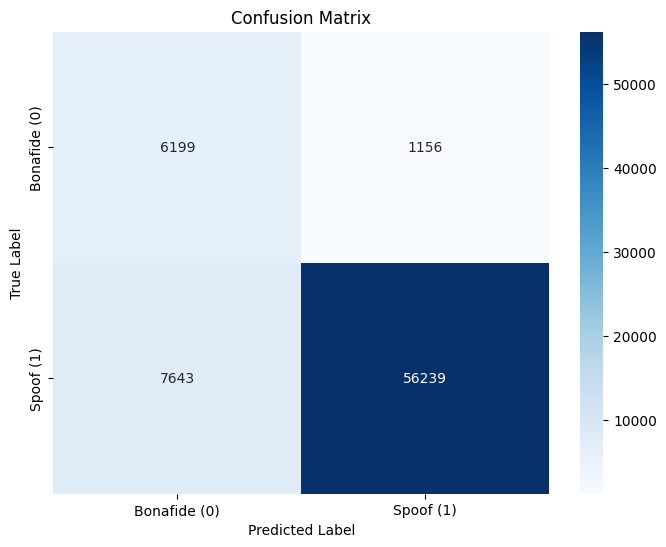

In [25]:
# Convert probabilities to class labels (0 or 1) using a 0.5 threshold
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()

print("✅ Predictions and labels are ready.")

# --- 3. Calculate Confusion Matrix ---
# Note: We must have the 'eval_dataset' variable
cm = confusion_matrix(y_true, y_pred_classes)

# --- 4. Plot the Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,     # Show the numbers in each cell
    fmt='d',        # Format as integers
    cmap='Blues',   # Color scheme
    xticklabels=['Bonafide (0)', 'Spoof (1)'],
    yticklabels=['Bonafide (0)', 'Spoof (1)']
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()